In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("olympics_medals_country_wise.csv")

# spaces
df.columns = df.columns.str.strip()
#int
columns_to_clean = [
    "summer_gold",
    "summer_total",
    "total_gold",
    "total_total"
]

for column in columns_to_clean:
    df[column] = df[column].str.replace(",", "")
    df[column] = pd.to_numeric(df[column])

# top 10 countries
top_10 = df.sort_values("total_total", ascending=False).head(10)

df["log_total"] = np.log10(df["total_total"])


original_corr = df["total_participation"].corr(df["total_total"])
log_corr = df["total_participation"].corr(df["log_total"])

print("Original correlation:", original_corr)
print("Log correlation:", log_corr)

Original correlation: 0.5003734310897389
Log correlation: 0.6343356366702985


In [2]:
print(df[["total_total", "log_total"]].head())

   total_total  log_total
0            2   0.301030
1           17   1.230449
2           77   1.886491
3           18   1.255273
4           12   1.079181


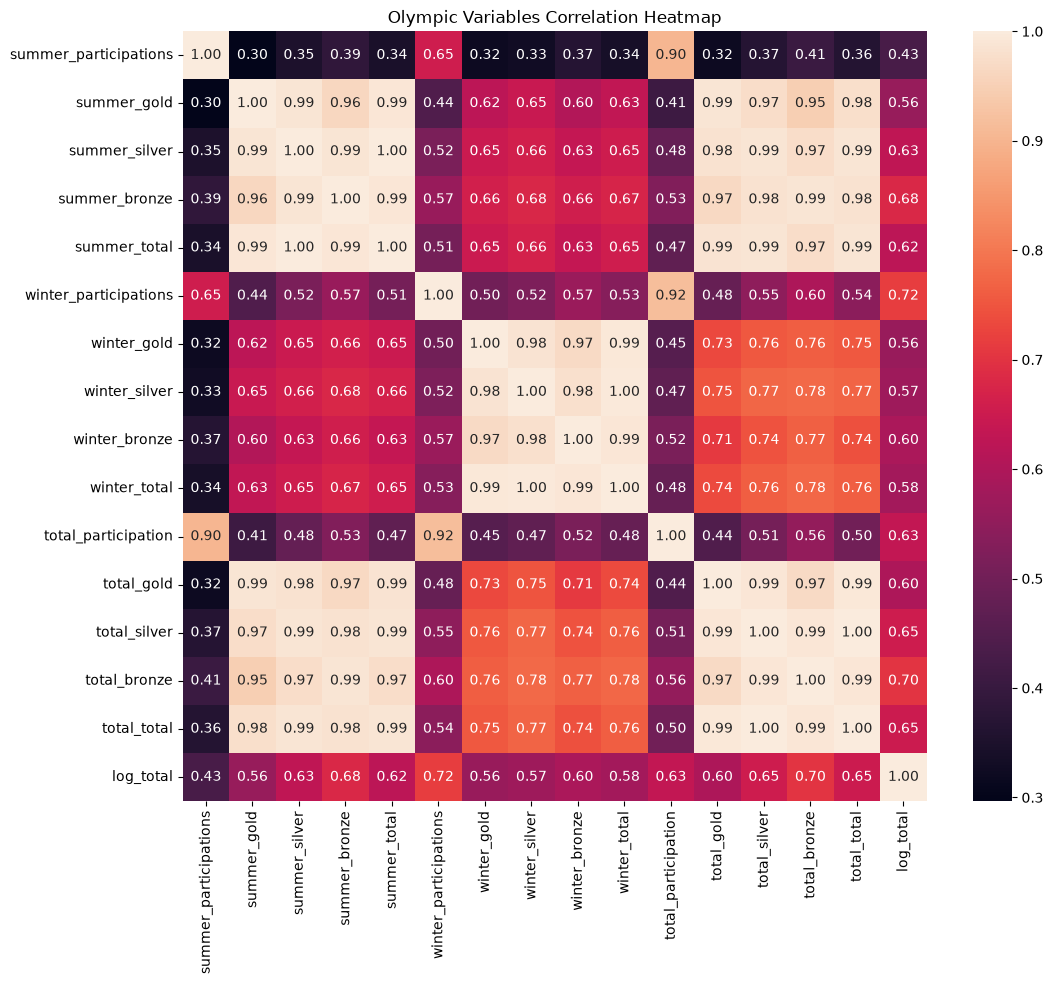

In [3]:
numeric_df = df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Olympic Variables Correlation Heatmap")

plt.show()

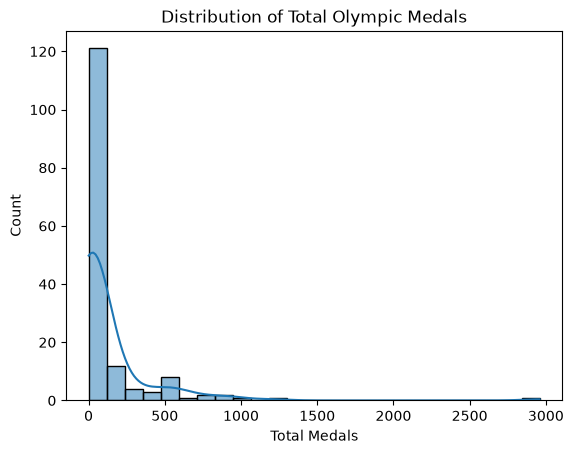

In [4]:
sns.histplot(data=df, x="total_total", kde=True)

plt.title("Distribution of Total Olympic Medals")
plt.xlabel("Total Medals")
plt.show()

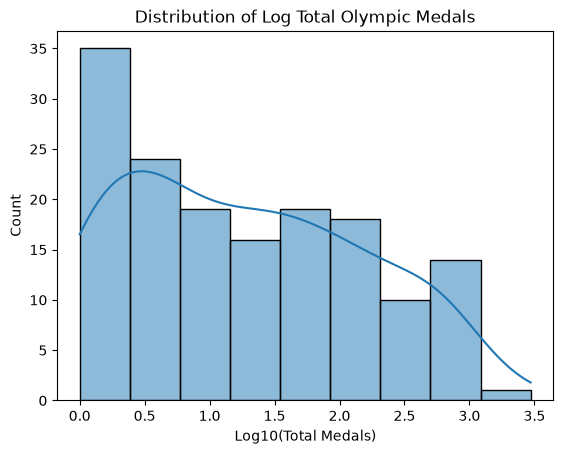

In [5]:
sns.histplot(data=df, x="log_total", kde=True)

plt.title("Distribution of Log Total Olympic Medals")
plt.xlabel("Log10(Total Medals)")
plt.show()

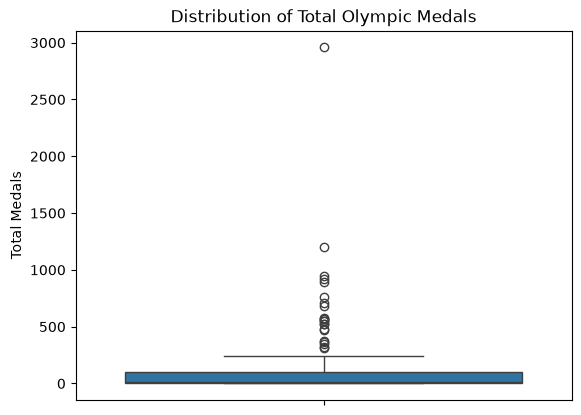

In [6]:
sns.boxplot(data=df, y="total_total")

plt.title("Distribution of Total Olympic Medals")
plt.ylabel("Total Medals")

plt.show()

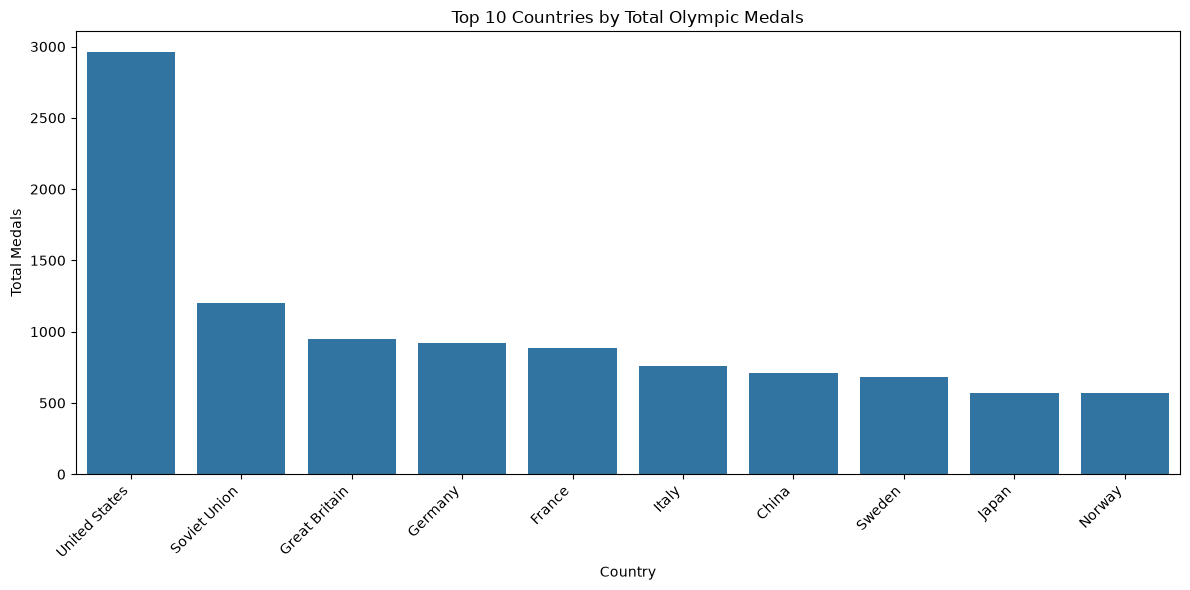

In [8]:
top_10 = df.sort_values(
    "total_total",
    ascending=False
).head(10)

top_10[["countries", "total_total"]]
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10,
    x="countries",
    y="total_total"
)

plt.title("Top 10 Countries by Total Olympic Medals")
plt.xlabel("Country")
plt.ylabel("Total Medals")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


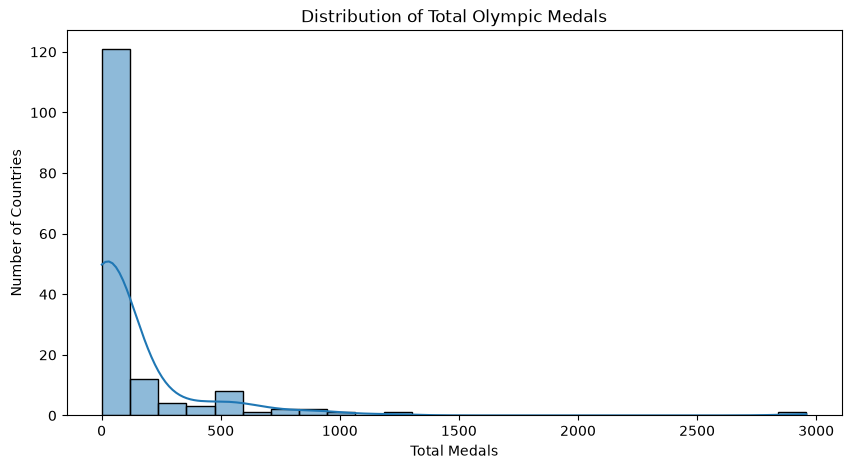

In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="total_total",
    kde=True
)

plt.title("Distribution of Total Olympic Medals")
plt.xlabel("Total Medals")
plt.ylabel("Number of Countries")

plt.show()

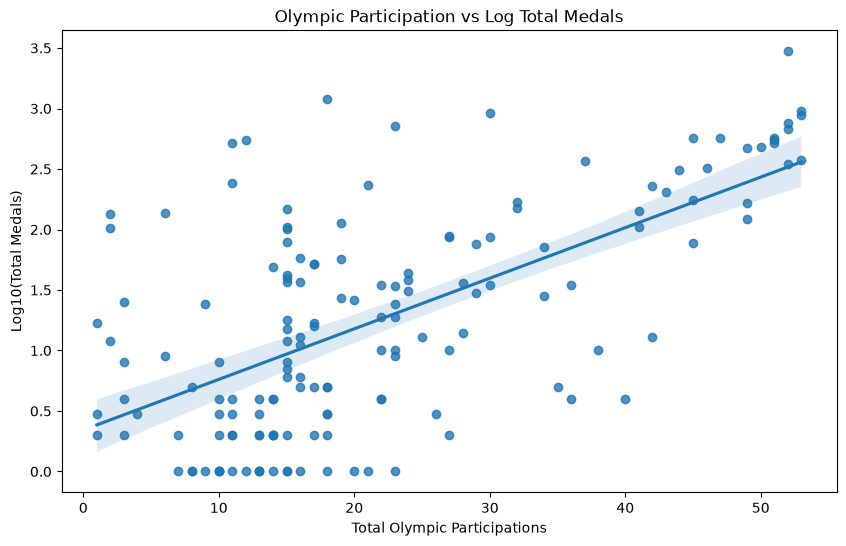

In [11]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="total_participation",
    y="log_total"
)

plt.title(
    "Olympic Participation vs Log Total Medals"
)

plt.xlabel("Total Olympic Participations")
plt.ylabel("Log10(Total Medals)")

plt.show()

Text(0, 0.5, 'idk')

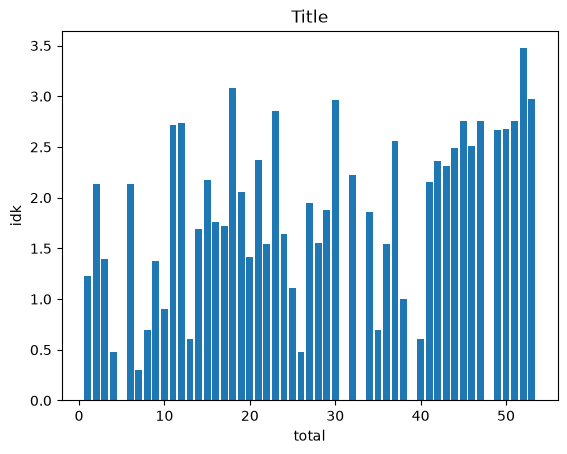

In [ ]:
sns.scatterplot()


plt.bar(df["total_participation"], df["log_total"])
plt.title("Title")
plt.xlabel("total")
plt.ylabel("idk")

In [26]:
top10_pcp = df.sort_values(
    "total_participation",
    ascending=False
).head(10)

print(top10_pcp[["countries", "ioc_code", "total_participation"]])

         countries ioc_code  total_participation
51   Great Britain    (GBR)                   53
129    Switzerland    (SUI)                   53
43          France    (FRA)                   53
6          Austria    (AUT)                   52
66           Italy    (ITA)                   52
128         Sweden    (SWE)                   52
144  United States    (USA)                   52
97          Norway    (NOR)                   51
58         Hungary    (HUN)                   51
22          Canada    (CAN)                   51
